In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

## Principal Component Analysis 


### Hyperparamaters 

`vocab_size=23`


`epoch=250`


`batch_size=128`




Epoch 1, Loss (Training): 2.8050 Loss(val): 2.4176
Epoch 2, Loss (Training): 2.1203 Loss(val): 1.8532
Epoch 3, Loss (Training): 1.6509 Loss(val): 1.4445
Epoch 4, Loss (Training): 1.2531 Loss(val): 1.0525
Epoch 5, Loss (Training): 0.8917 Loss(val): 0.7429
Epoch 6, Loss (Training): 0.6352 Loss(val): 0.5305
Epoch 7, Loss (Training): 0.4609 Loss(val): 0.3951
Epoch 8, Loss (Training): 0.3522 Loss(val): 0.3096
Epoch 9, Loss (Training): 0.2776 Loss(val): 0.2418
Epoch 10, Loss (Training): 0.2157 Loss(val): 0.1884
Epoch 11, Loss (Training): 0.1681 Loss(val): 0.1474
Epoch 12, Loss (Training): 0.1337 Loss(val): 0.1196
Epoch 13, Loss (Training): 0.1102 Loss(val): 0.1005
Epoch 14, Loss (Training): 0.0932 Loss(val): 0.0851
Epoch 15, Loss (Training): 0.0793 Loss(val): 0.0715
Epoch 16, Loss (Training): 0.0661 Loss(val): 0.0587
Epoch 17, Loss (Training): 0.0540 Loss(val): 0.0476
Epoch 18, Loss (Training): 0.0440 Loss(val): 0.0391
Epoch 19, Loss (Training): 0.0362 Loss(val): 0.0324
Epoch 20, Loss (Train

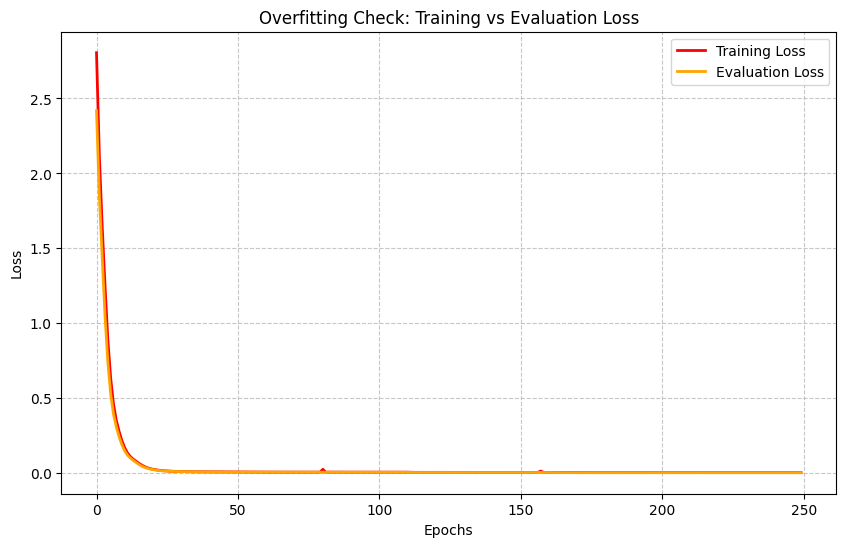

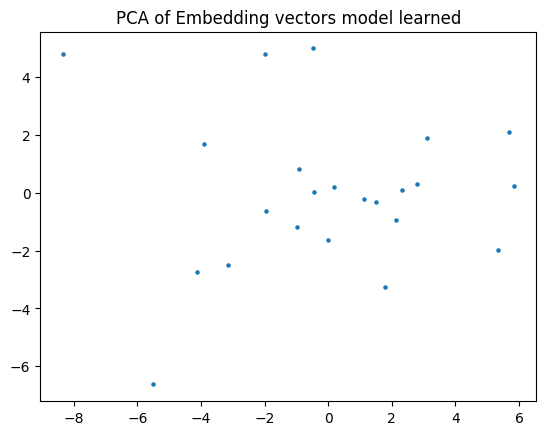

In [ ]:
import time
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torch.utils.data import Dataset, DataLoader, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class FibonacciModDataset(Dataset):
    def __init__(self, seq_len=10, mod=10, num_samples=10000):
        self.mod = mod

        self.global_seq = self.generate_fib_sequence(1000, mod)
        self.samples = []
        for _ in range(num_samples):
            start_idx = torch.randint(0, len(self.global_seq) - seq_len - 1, (1,)).item()
            seq = self.global_seq[start_idx:start_idx + seq_len + 1]
            x = torch.tensor(seq[:-1], dtype=torch.long)
            y = torch.tensor(seq[1:], dtype=torch.long)
            self.samples.append((x, y))

    def generate_fib_sequence(self, length, mod):
        seq = [1, 1] # these are the starting values
        while len(seq) < length: # this prevents overlap
            seq.append((seq[-1] + seq[-2]) % mod)
        return seq

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

class MinimalTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=8, n_heads=1, num_layers=1, max_seq_len=20):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, d_model)
        self.pos_embed = nn.Embedding(max_seq_len, d_model)
        self.layers = nn.ModuleList([
            nn.MultiheadAttention(d_model, n_heads, batch_first=True)
            for _ in range(num_layers)
        ])
        self.out_proj = nn.Linear(d_model, vocab_size)

    def forward(self, tokens):
        B, T = tokens.shape
        pos = torch.arange(T, device=tokens.device)
        x = self.token_embed(tokens) + self.pos_embed(pos).unsqueeze(0)
        attn_mask = torch.triu(torch.ones(T, T, device=tokens.device) * float('-inf'), diagonal=1)
        for attn in self.layers:
            attn_out, _ = attn(x, x, x, attn_mask=attn_mask)
            x = x + attn_out
        return self.out_proj(x)
    
    def get_embeddings(self):
        return self.pos_embed + self.token_embed
    


train_plot = []
eval_plot = []
def train_model(model, dataloader, test_loader, epochs=12, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train() # because we have that eval mode after each epoch
        total_loss = 0
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            
            logits = model(x)
            loss = loss_fn(logits[:, 1:].reshape(-1, logits.size(-1)), y[:, 1:].reshape(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        train_plot.append({'loss': avg_loss, 'epoch': epoch})  
        
        model.eval()
        with torch.no_grad():
            val_loss = evaluate_model(model, test_loader)
            eval_plot.append(val_loss)
    
        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1}, Loss (Training): {avg_loss:.4f} Loss(val): {val_loss:.4f}")
    
    end_time = time.time()
    print(f"Total Training Time: {end_time - start_time:.2f} seconds")


def evaluate_model(model, dataloader, show_accuracy = False):
    correct, total = 0, 0
    loss_fn = nn.CrossEntropyLoss()
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            pred = logits.argmax(dim=-1)

            loss = loss_fn(logits[:, 1:].reshape(-1, logits.size(-1)), y[:, 1:].reshape(-1))
            total_loss += loss.item()

            correct += (pred[:, 1:] == y[:, 1:]).sum().item()
            total += y[:, 1:].numel()

    if show_accuracy:
      print(f"Accuracy (eval mode): {correct / total:.2%}")

    avg_loss = total_loss / len(dataloader) 
    return avg_loss

vocab_size = 23
batch_size = 128
generated_ds = FibonacciModDataset(num_samples=25000, mod=vocab_size, seq_len=20)



train_size = int(0.8 * len(generated_ds))
test_size = len(generated_ds) - train_size
train_ds, test_ds = random_split(generated_ds, [train_size, test_size]) 

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)
test_loader = DataLoader(test_ds, batch_size=batch_size, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)


model = MinimalTransformer(vocab_size=vocab_size).to(device)

train_model(model, train_loader, epochs=250, test_loader=test_loader)
evaluate_model(model, test_loader, show_accuracy=True)

def overfitting_plot(train_history, eval_losses):
    epochs = [x['epoch'] for x in train_history]
    train_losses = [x['loss'] for x in train_history]
    
    plt.figure(figsize=(10, 6))

    plt.plot(epochs, train_losses, label='Training Loss', color='red', linewidth=2)
    plt.plot(epochs, eval_losses, label='Evaluation Loss', color='orange', linewidth=2)

    plt.title('Overfitting Check: Training vs Evaluation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
overfitting_plot(train_plot, eval_plot)


embedding_learned = model.token_embed
B, T = embedding_learned.weight.shape

# extract vectors
embedding_matrix = embedding_learned.weight.detach()
X = embedding_matrix.cpu().numpy() # to numpy

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], s=5)
plt.title("PCA of Embedding vectors model learned")
plt.show()



### Hyperparamaters 

`vocab_size=10`


`epoch=250`


`batch_size=128`



Epoch 1, Loss (Training): 2.3382 Loss(val): 2.1902
Epoch 2, Loss (Training): 2.1120 Loss(val): 2.0460
Epoch 3, Loss (Training): 1.9660 Loss(val): 1.8739
Epoch 4, Loss (Training): 1.6997 Loss(val): 1.4820
Epoch 5, Loss (Training): 1.2275 Loss(val): 0.9953
Epoch 6, Loss (Training): 0.8405 Loss(val): 0.7153
Epoch 7, Loss (Training): 0.6480 Loss(val): 0.5954
Epoch 8, Loss (Training): 0.5625 Loss(val): 0.5314
Epoch 9, Loss (Training): 0.5077 Loss(val): 0.4827
Epoch 10, Loss (Training): 0.4599 Loss(val): 0.4354
Epoch 11, Loss (Training): 0.4075 Loss(val): 0.3742
Epoch 12, Loss (Training): 0.3424 Loss(val): 0.3170
Epoch 13, Loss (Training): 0.2986 Loss(val): 0.2823
Epoch 14, Loss (Training): 0.2682 Loss(val): 0.2557
Epoch 15, Loss (Training): 0.2440 Loss(val): 0.2345
Epoch 16, Loss (Training): 0.2248 Loss(val): 0.2167
Epoch 17, Loss (Training): 0.2086 Loss(val): 0.2022
Epoch 18, Loss (Training): 0.1954 Loss(val): 0.1897
Epoch 19, Loss (Training): 0.1837 Loss(val): 0.1786
Epoch 20, Loss (Train

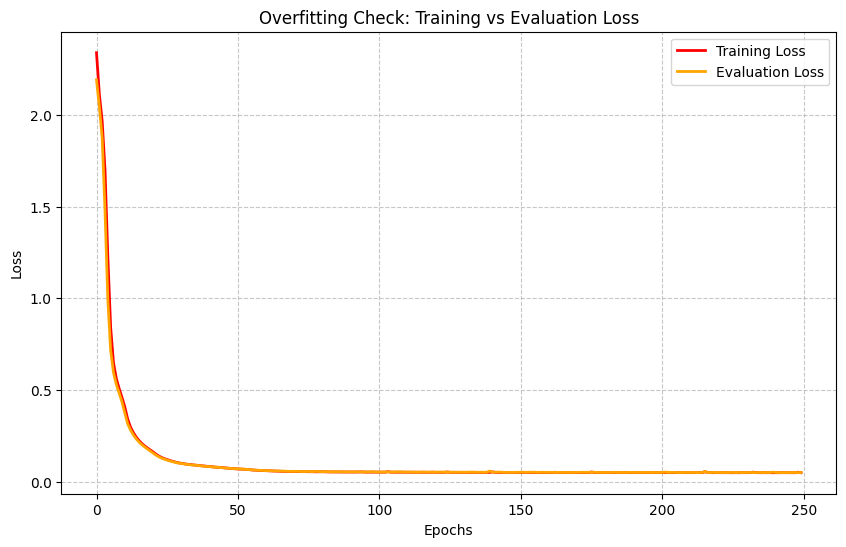

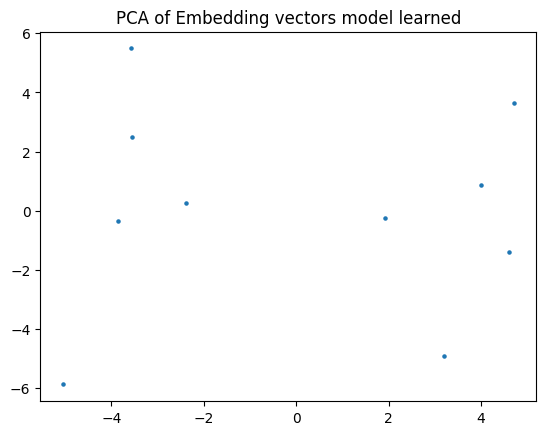

In [1]:
import time
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torch.utils.data import Dataset, DataLoader, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class FibonacciModDataset(Dataset):
    def __init__(self, seq_len=10, mod=10, num_samples=10000):
        self.mod = mod

        self.global_seq = self.generate_fib_sequence(1000, mod)
        self.samples = []
        for _ in range(num_samples):
            start_idx = torch.randint(0, len(self.global_seq) - seq_len - 1, (1,)).item()
            seq = self.global_seq[start_idx:start_idx + seq_len + 1]
            x = torch.tensor(seq[:-1], dtype=torch.long)
            y = torch.tensor(seq[1:], dtype=torch.long)
            self.samples.append((x, y))

    def generate_fib_sequence(self, length, mod):
        seq = [1, 1] # these are the starting values
        while len(seq) < length: # this prevents overlap
            seq.append((seq[-1] + seq[-2]) % mod)
        return seq

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

class MinimalTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=8, n_heads=1, num_layers=1, max_seq_len=20):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, d_model)
        self.pos_embed = nn.Embedding(max_seq_len, d_model)
        self.layers = nn.ModuleList([
            nn.MultiheadAttention(d_model, n_heads, batch_first=True)
            for _ in range(num_layers)
        ])
        self.out_proj = nn.Linear(d_model, vocab_size)

    def forward(self, tokens):
        B, T = tokens.shape
        pos = torch.arange(T, device=tokens.device)
        x = self.token_embed(tokens) + self.pos_embed(pos).unsqueeze(0)
        attn_mask = torch.triu(torch.ones(T, T, device=tokens.device) * float('-inf'), diagonal=1)
        for attn in self.layers:
            attn_out, _ = attn(x, x, x, attn_mask=attn_mask)
            x = x + attn_out
        return self.out_proj(x)
    
    def get_embeddings(self):
        return self.pos_embed + self.token_embed
    


train_plot = []
eval_plot = []
def train_model(model, dataloader, test_loader, epochs=12, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train() # because we have that eval mode after each epoch
        total_loss = 0
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            
            logits = model(x)
            loss = loss_fn(logits[:, 1:].reshape(-1, logits.size(-1)), y[:, 1:].reshape(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        train_plot.append({'loss': avg_loss, 'epoch': epoch})  
        
        model.eval()
        with torch.no_grad():
            val_loss = evaluate_model(model, test_loader)
            eval_plot.append(val_loss)
    
        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1}, Loss (Training): {avg_loss:.4f} Loss(val): {val_loss:.4f}")
    
    end_time = time.time()
    print(f"Total Training Time: {end_time - start_time:.2f} seconds")


def evaluate_model(model, dataloader, show_accuracy = False):
    correct, total = 0, 0
    loss_fn = nn.CrossEntropyLoss()
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            pred = logits.argmax(dim=-1)

            loss = loss_fn(logits[:, 1:].reshape(-1, logits.size(-1)), y[:, 1:].reshape(-1))
            total_loss += loss.item()

            correct += (pred[:, 1:] == y[:, 1:]).sum().item()
            total += y[:, 1:].numel()

    if show_accuracy:
      print(f"Accuracy (eval mode): {correct / total:.2%}")

    avg_loss = total_loss / len(dataloader) 
    return avg_loss

vocab_size = 10
batch_size = 128
generated_ds = FibonacciModDataset(num_samples=25000, mod=vocab_size, seq_len=20)



train_size = int(0.8 * len(generated_ds))
test_size = len(generated_ds) - train_size
train_ds, test_ds = random_split(generated_ds, [train_size, test_size]) 

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)
test_loader = DataLoader(test_ds, batch_size=batch_size, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)


model = MinimalTransformer(vocab_size=vocab_size).to(device)

train_model(model, train_loader, epochs=250, test_loader=test_loader)
evaluate_model(model, test_loader, show_accuracy=True)

def overfitting_plot(train_history, eval_losses):
    epochs = [x['epoch'] for x in train_history]
    train_losses = [x['loss'] for x in train_history]
    
    plt.figure(figsize=(10, 6))

    plt.plot(epochs, train_losses, label='Training Loss', color='red', linewidth=2)
    plt.plot(epochs, eval_losses, label='Evaluation Loss', color='orange', linewidth=2)

    plt.title('Overfitting Check: Training vs Evaluation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
overfitting_plot(train_plot, eval_plot)


embedding_learned = model.token_embed
B, T = embedding_learned.weight.shape

# extract vectors
embedding_matrix = embedding_learned.weight.detach()
X = embedding_matrix.cpu().numpy() # to numpy

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], s=5)
plt.title("PCA of Embedding vectors model learned")
plt.show()


### Same paramaters just different `n_head=2`

Epoch 1, Loss (Training): 2.2974 Loss(val): 2.1203
Epoch 2, Loss (Training): 2.0187 Loss(val): 1.9060
Epoch 3, Loss (Training): 1.7947 Loss(val): 1.6884
Epoch 4, Loss (Training): 1.5728 Loss(val): 1.4613
Epoch 5, Loss (Training): 1.3636 Loss(val): 1.2849
Epoch 6, Loss (Training): 1.2185 Loss(val): 1.1538
Epoch 7, Loss (Training): 1.0829 Loss(val): 1.0176
Epoch 8, Loss (Training): 0.9368 Loss(val): 0.8512
Epoch 9, Loss (Training): 0.7458 Loss(val): 0.6354
Epoch 10, Loss (Training): 0.5379 Loss(val): 0.4631
Epoch 11, Loss (Training): 0.4056 Loss(val): 0.3660
Epoch 12, Loss (Training): 0.3307 Loss(val): 0.3049
Epoch 13, Loss (Training): 0.2772 Loss(val): 0.2552
Epoch 14, Loss (Training): 0.2271 Loss(val): 0.2027
Epoch 15, Loss (Training): 0.1794 Loss(val): 0.1585
Epoch 16, Loss (Training): 0.1360 Loss(val): 0.1149
Epoch 17, Loss (Training): 0.0946 Loss(val): 0.0773
Epoch 18, Loss (Training): 0.0629 Loss(val): 0.0512
Epoch 19, Loss (Training): 0.0417 Loss(val): 0.0340
Epoch 20, Loss (Train

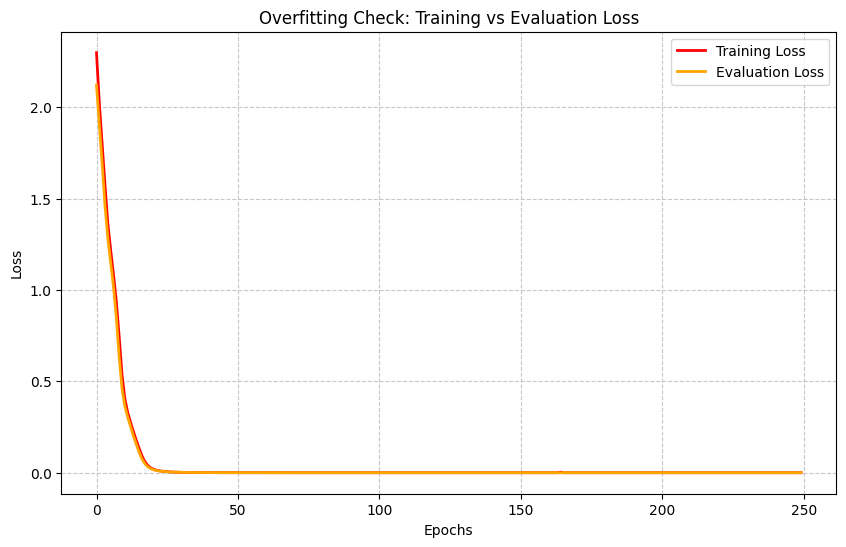

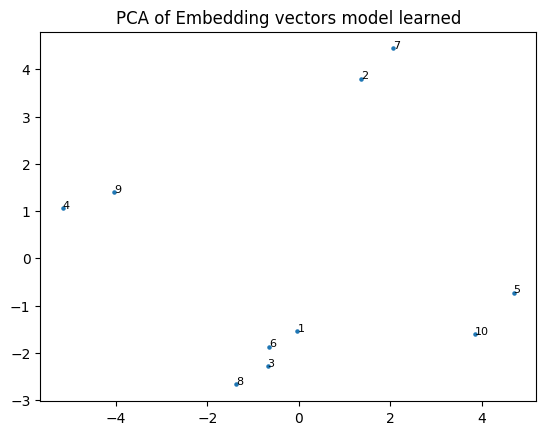

In [4]:
import time
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torch.utils.data import Dataset, DataLoader, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class FibonacciModDataset(Dataset):
    def __init__(self, seq_len=10, mod=10, num_samples=10000):
        self.mod = mod

        self.global_seq = self.generate_fib_sequence(1000, mod)
        self.samples = []
        for _ in range(num_samples):
            start_idx = torch.randint(0, len(self.global_seq) - seq_len - 1, (1,)).item()
            seq = self.global_seq[start_idx:start_idx + seq_len + 1]
            x = torch.tensor(seq[:-1], dtype=torch.long)
            y = torch.tensor(seq[1:], dtype=torch.long)
            self.samples.append((x, y))

    def generate_fib_sequence(self, length, mod):
        seq = [1, 1] # these are the starting values
        while len(seq) < length: # this prevents overlap
            seq.append((seq[-1] + seq[-2]) % mod)
        return seq

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

class MinimalTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=8, n_heads=2, num_layers=1, max_seq_len=20):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, d_model)
        self.pos_embed = nn.Embedding(max_seq_len, d_model)
        self.layers = nn.ModuleList([
            nn.MultiheadAttention(d_model, n_heads, batch_first=True)
            for _ in range(num_layers)
        ])
        self.out_proj = nn.Linear(d_model, vocab_size)
        self.vocab_size = vocab_size

    def forward(self, tokens):
        B, T = tokens.shape
        pos = torch.arange(T, device=tokens.device)
        x = self.token_embed(tokens) + self.pos_embed(pos).unsqueeze(0)
        attn_mask = torch.triu(torch.ones(T, T, device=tokens.device) * float('-inf'), diagonal=1)
        for attn in self.layers:
            attn_out, _ = attn(x, x, x, attn_mask=attn_mask)
            x = x + attn_out
        return self.out_proj(x)
    
    def get_embeddings(self):
        return self.pos_embed + self.token_embed
    


train_plot = []
eval_plot = []
def train_model(model, dataloader, test_loader, epochs=12, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train() # because we have that eval mode after each epoch
        total_loss = 0
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            
            logits = model(x)
            loss = loss_fn(logits[:, 1:].reshape(-1, logits.size(-1)), y[:, 1:].reshape(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        train_plot.append({'loss': avg_loss, 'epoch': epoch})  
        
        model.eval()
        with torch.no_grad():
            val_loss = evaluate_model(model, test_loader)
            eval_plot.append(val_loss)
    
        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1}, Loss (Training): {avg_loss:.4f} Loss(val): {val_loss:.4f}")
    
    end_time = time.time()
    print(f"Total Training Time: {end_time - start_time:.2f} seconds")


def evaluate_model(model, dataloader, show_accuracy = False):
    correct, total = 0, 0
    loss_fn = nn.CrossEntropyLoss()
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            pred = logits.argmax(dim=-1)

            loss = loss_fn(logits[:, 1:].reshape(-1, logits.size(-1)), y[:, 1:].reshape(-1))
            total_loss += loss.item()

            correct += (pred[:, 1:] == y[:, 1:]).sum().item()
            total += y[:, 1:].numel()

    if show_accuracy:
      print(f"Accuracy (eval mode): {correct / total:.2%}")

    avg_loss = total_loss / len(dataloader) 
    return avg_loss

vocab_size = 10
batch_size = 128
generated_ds = FibonacciModDataset(num_samples=25000, mod=vocab_size, seq_len=20)



train_size = int(0.8 * len(generated_ds))
test_size = len(generated_ds) - train_size
train_ds, test_ds = random_split(generated_ds, [train_size, test_size]) 

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)
test_loader = DataLoader(test_ds, batch_size=batch_size, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)


model = MinimalTransformer(vocab_size=vocab_size).to(device)

train_model(model, train_loader, epochs=250, test_loader=test_loader)
evaluate_model(model, test_loader, show_accuracy=True)

def overfitting_plot(train_history, eval_losses):
    epochs = [x['epoch'] for x in train_history]
    train_losses = [x['loss'] for x in train_history]
    
    plt.figure(figsize=(10, 6))

    plt.plot(epochs, train_losses, label='Training Loss', color='red', linewidth=2)
    plt.plot(epochs, eval_losses, label='Evaluation Loss', color='orange', linewidth=2)

    plt.title('Overfitting Check: Training vs Evaluation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
overfitting_plot(train_plot, eval_plot)


embedding_learned = model.token_embed
B, T = embedding_learned.weight.shape

# extract vectors
embedding_matrix = embedding_learned.weight.detach()
X = embedding_matrix.cpu().numpy() # to numpy

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

for i in range(len(X_pca)):
    plt.annotate(str(i + 1), (X_pca[i, 0], X_pca[i, 1]), fontsize=8)


plt.scatter(X_pca[:,0], X_pca[:,1], s=5)
plt.title("PCA of Embedding vectors model learned")
plt.show()